# Is a "failure scenario" a property of the context, or of one draw?

Issue #73 proposes mining rollouts that "diverge hugely from the true data" into a pool
and continuing training on that pool. Everything downstream of that, including the
70/30 replay question, assumes the pool is a set of contexts the model genuinely
handles badly. Three things have to hold before that assumption is safe, and all three
are measurable on rollouts that already exist, on CPU, in seconds.

| | Question | Fails how |
|---|---|---|
| **R** | Score a context from one set of rollouts, score it again from a disjoint set. Do the two rankings agree? | Generation here is not seed-reproducible (XLA autotuning). If the rankings disagree, "this context failed" describes the draw, not the context. |
| **C** | Destroy the rollout-to-context pairing. Does the ranking change? | A score that survives shuffling is a marginal statistic. It ranks contexts by something that is not the model's behaviour on them. |
| **D** | Split the selected-on error into a systematic part and a dispersion part. Which dominates? | Only the systematic part is learnable. Dispersion means the model spread its mass wide and one realised path fell off centre, which is a correct forecast meeting one draw. |

**Data.** 8 tickers, 500 frozen contexts each, one realised future per context, and 10
independently seeded rollouts per context, at 7 forward horizons. Plus two complete
independent regenerations of the same configuration with the same seeds, which is the
only way to see the generation-nondeterminism layer at all.

    /lus/lfs1aip2/projects/public/u6gb/tasks/crps_return_alignment_20260808T025024Z/data/
        hp_v5me3_<TICKER>_s<SEED>/member_0/.returns_multih_{real,gen}.npz

**Measurement code and its tests.**

    /lus/lfs1aip2/projects/public/u6gb/tasks/continual_learning/code/failure_pool_reliability.py
    /lus/lfs1aip2/projects/public/u6gb/tasks/continual_learning/code/test_failure_pool_reliability.py


In [1]:
import io, json, sys
from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

CODE = Path("/lus/lfs1aip2/projects/public/u6gb/tasks/continual_learning/code")
RES  = Path("/lus/lfs1aip2/projects/public/u6gb/tasks/continual_learning/results")
sys.path.insert(0, str(CODE))
import failure_pool_reliability as F

mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.4,
    "legend.frameon": False, "axes.titlesize": 9, "axes.labelsize": 8,
})

def show(fig):
    """Render at 300 dpi, then quantise to a 256-colour palette before embedding.

    dpi decides the pixel count and therefore the byte count; a 300 dpi PNG is
    roughly nine times the size of the same figure at 100. Palette quantisation
    buys most of that back without touching figsize, which would shrink the
    figure while leaving the font sizes in points and make the labels collide.
    """
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", facecolor="white")
    plt.close(fig)
    buf.seek(0)
    q = Image.open(buf).convert("RGB").quantize(colors=256, method=Image.MEDIANCUT)
    out = io.BytesIO(); q.save(out, format="PNG", optimize=True)
    display(Image.open(io.BytesIO(out.getvalue())))

R = json.loads((RES / "failure_pool_reliability.json").read_text())
TK = [t for t, v in R["tickers"].items() if "split_half_raw" in v]
HZ = F.HORIZONS
H  = 2   # the single-horizon readouts use horizon 50
CB = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3",
      "#937860", "#DA8BC3", "#8C8C8C"]
print(f"{len(TK)} tickers | {R['tickers'][TK[0]]['n_contexts']} contexts each | "
      f"{R['tickers'][TK[0]]['n_seeds']} rollouts per context | horizons {list(HZ)}")

8 tickers | 500 contexts each | 10 rollouts per context | horizons [10, 25, 50, 100, 150, 200, 250]


## Figure 1 — One rollout per context ranks almost nothing

Two disjoint sets of `k` rollouts score the same 500 contexts; the bars are the rank
correlation between the two scorings. Left is the raw squared error against the realised
path, which is what "diverges hugely from the true data" means literally. Right is the
same error ranked inside bins of realised move size, which is the correction Figure 2
will show is necessary.

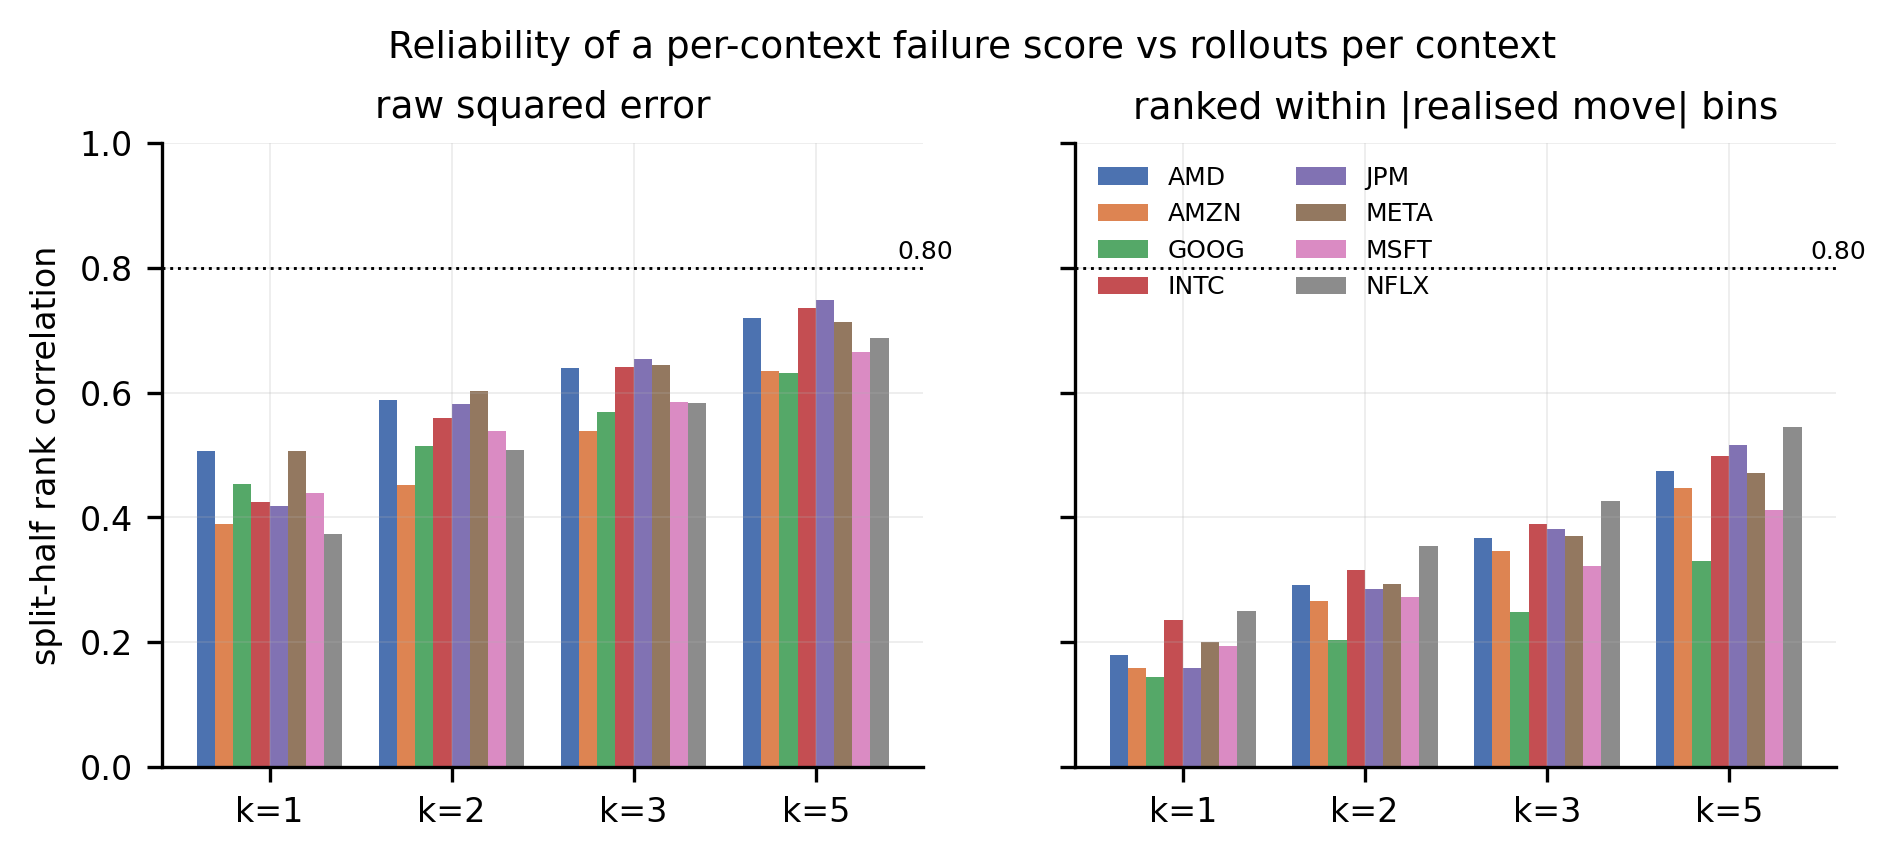

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.7), sharey=True)
for ax, key, title in zip(
        axes, ["split_half_raw", "split_half_stratified"],
        ["raw squared error", "ranked within |realised move| bins"]):
    ks = [r["k"] for r in R["tickers"][TK[0]][key]]
    w  = 0.10
    for i, t in enumerate(TK):
        rows = R["tickers"][t][key]
        ax.bar([x + (i - 3.5) * w for x in range(len(ks))],
               [r["rho_mean"] for r in rows], width=w, color=CB[i], label=t)
    ax.axhline(0.8, color="k", ls=":", lw=0.7)
    ax.text(len(ks) - 0.55, 0.815, "0.80", fontsize=6, color="k")
    ax.set_xticks(range(len(ks))); ax.set_xticklabels([f"k={k}" for k in ks])
    ax.set_title(title); ax.set_ylim(0, 1.0)
axes[0].set_ylabel("split-half rank correlation")
axes[1].legend(ncol=2, fontsize=6, loc="upper left")
fig.suptitle("Reliability of a per-context failure score vs rollouts per context",
             y=1.02, fontsize=9)
show(fig)

A single rollout per context reaches 0.36-0.48 on the raw score and 0.15-0.25 on the
corrected one. A pool built from one rollout per context is roughly half noise on the
first score and mostly noise on the second.

## Figure 2 — Most of the raw signal is the size of the realised move, not the model

Two diagnostics of the same score. Left: rank correlation against the absolute realised
return, a property of the context that is byte-identical across every seed. Right: rank
correlation between the true ranking and the ranking obtained after permuting which
rollouts belong to which context. A score that survives that permutation is not scoring
the model's behaviour on the context.

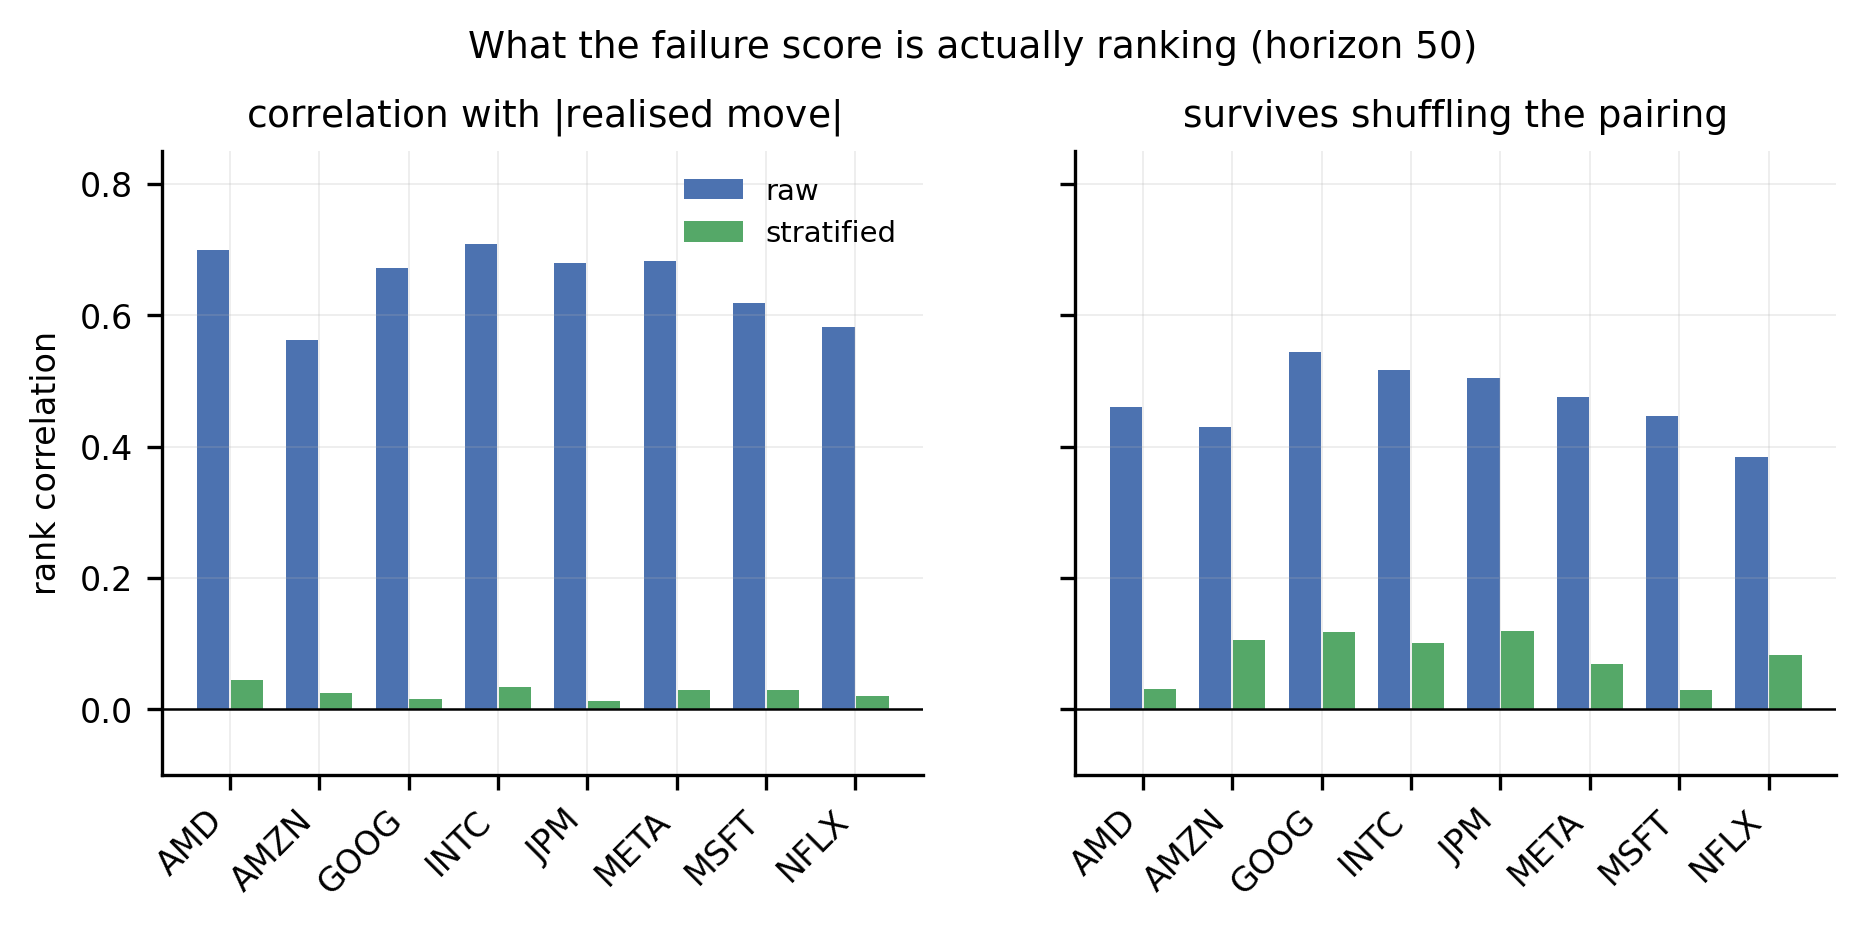

In [3]:
rng = np.random.default_rng(11)
rows = []
for t in TK:
    real, gen, _ = F.load_arm(F.DEFAULT_ROOT, "v5me3", t)
    y = real[:, H]
    perm = rng.permutation(real.shape[0])
    raw  = F.scores(real, gen)["total"][:, H]
    rawS = F.scores(real, gen[:, perm])["total"][:, H]
    st, stS = F.stratify(raw, y), F.stratify(rawS, y)
    rows.append(dict(ticker=t,
                     raw_y=F.spearman(raw, np.abs(y)),  raw_sh=F.spearman(raw, rawS),
                     st_y=F.spearman(st, np.abs(y)),    st_sh=F.spearman(st, stS)))

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.7), sharey=True)
x = np.arange(len(TK))
for ax, (a, b), title in zip(
        axes, [("raw_y", "st_y"), ("raw_sh", "st_sh")],
        [r"correlation with $|$realised move$|$", "survives shuffling the pairing"]):
    ax.bar(x - 0.19, [r[a] for r in rows], 0.36, color=CB[0], label="raw")
    ax.bar(x + 0.19, [r[b] for r in rows], 0.36, color=CB[2], label="stratified")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xticks(x); ax.set_xticklabels(TK, rotation=45, ha="right")
    ax.set_title(title); ax.set_ylim(-0.1, 0.85)
axes[0].set_ylabel("rank correlation"); axes[0].legend(fontsize=7)
fig.suptitle("What the failure score is actually ranking (horizon 50)", y=1.03, fontsize=9)
show(fig)

The raw score correlates 0.65 with the realised move size and keeps 0.46 of its
ranking after the rollouts are detached from their contexts. Both drop to about 0.03 and
0.10 once the score is ranked within realised-move bins. The correction is what turns a
marginal statistic into a conditional one.

## Figure 3 — Reliability on its own certifies nothing

Four readings of the same split-half comparison, differing only in how the
rollout-to-context pairing is broken. `shared` uses one permutation for both halves, so
both halves are wrong in the same way. It is as reliable as the truth, sometimes more so:
two halves can agree perfectly on a mis-paired score because the mis-pairing is something
they have in common.

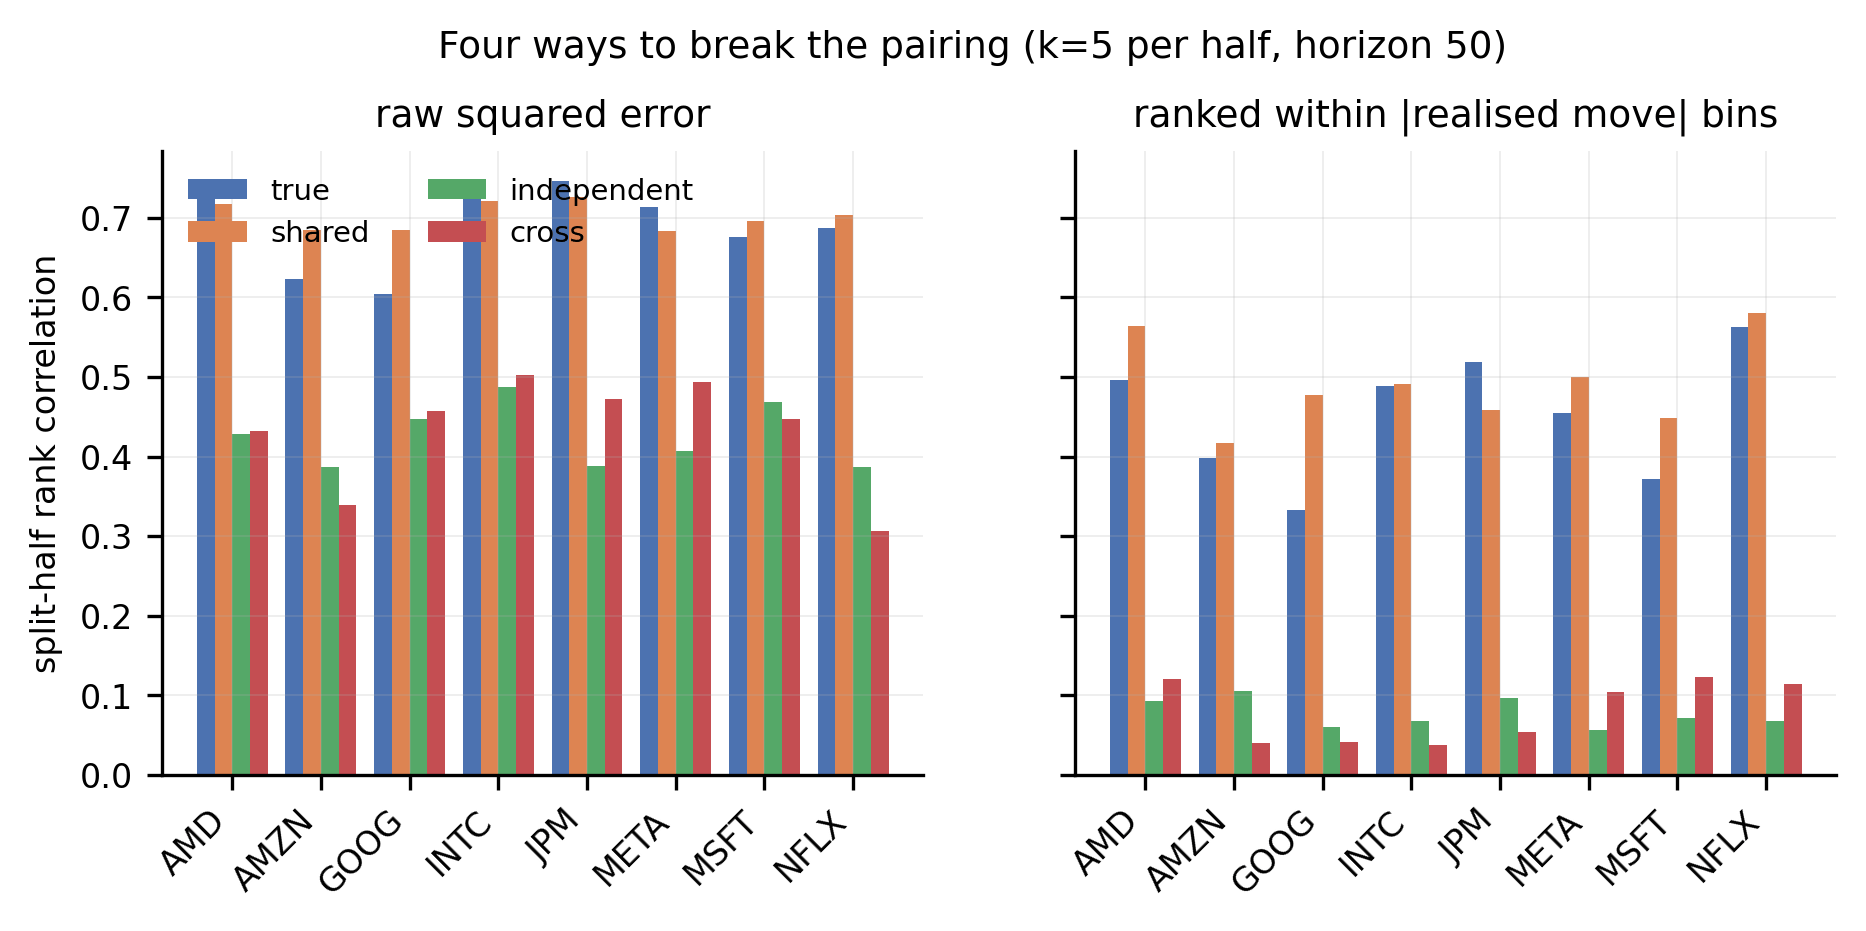

In [4]:
labs = ["true", "shared", "independent", "cross"]
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.7), sharey=True)
for ax, key, title in zip(axes, ["nulls_raw", "nulls_stratified"],
                          ["raw squared error", "ranked within |realised move| bins"]):
    x = np.arange(len(TK))
    for j, L in enumerate(labs):
        ax.bar(x + (j - 1.5) * 0.2, [R["tickers"][t][key][L] for t in TK], 0.2,
               color=CB[j], label=L if key == "nulls_raw" else None)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xticks(x); ax.set_xticklabels(TK, rotation=45, ha="right")
    ax.set_title(title)
axes[0].set_ylabel("split-half rank correlation"); axes[0].legend(fontsize=7, ncol=2)
fig.suptitle("Four ways to break the pairing (k=5 per half, horizon 50)", y=1.03, fontsize=9)
show(fig)

Read the two panels differently, because `independent` means different things in them.

On the **raw** score `independent` sits at 0.40-0.47. Each half was permuted separately,
so the two halves have no pairing in common at all, and they still agree on how to rank
the contexts. That is the cleanest single statement of the problem: the raw score ranks
contexts by something no permutation can disturb, namely how far the realised path moved.
`cross` sits at the same level for the same reason.

On the **stratified** score `independent` falls to 0.06-0.12 and becomes an actual zero
line, and `cross` collapses onto it while `true` stays at 0.33-0.55. A correctly paired
half no longer agrees with a permuted one, which is the evidence that what survives is
about the model's behaviour on that specific context.

The first version of this analysis used the `shared` construction as its null and read
0.49 where the answer should have been 0. `test_cross_null_separates_conditional_from_marginal`
in the test file goes red on exactly that mistake.

## Figure 4 — How much of the selected-on error is dispersion

Total squared error against the single realised path splits exactly:

$$\frac{1}{k}\sum_i (x_i - y)^2 \;=\; (\bar{x} - y)^2 \;+\; \mathrm{Var}_i(x)$$

The second term is the model saying it does not know. Selecting on the left-hand side
over-weights whichever regimes carry the most of it.

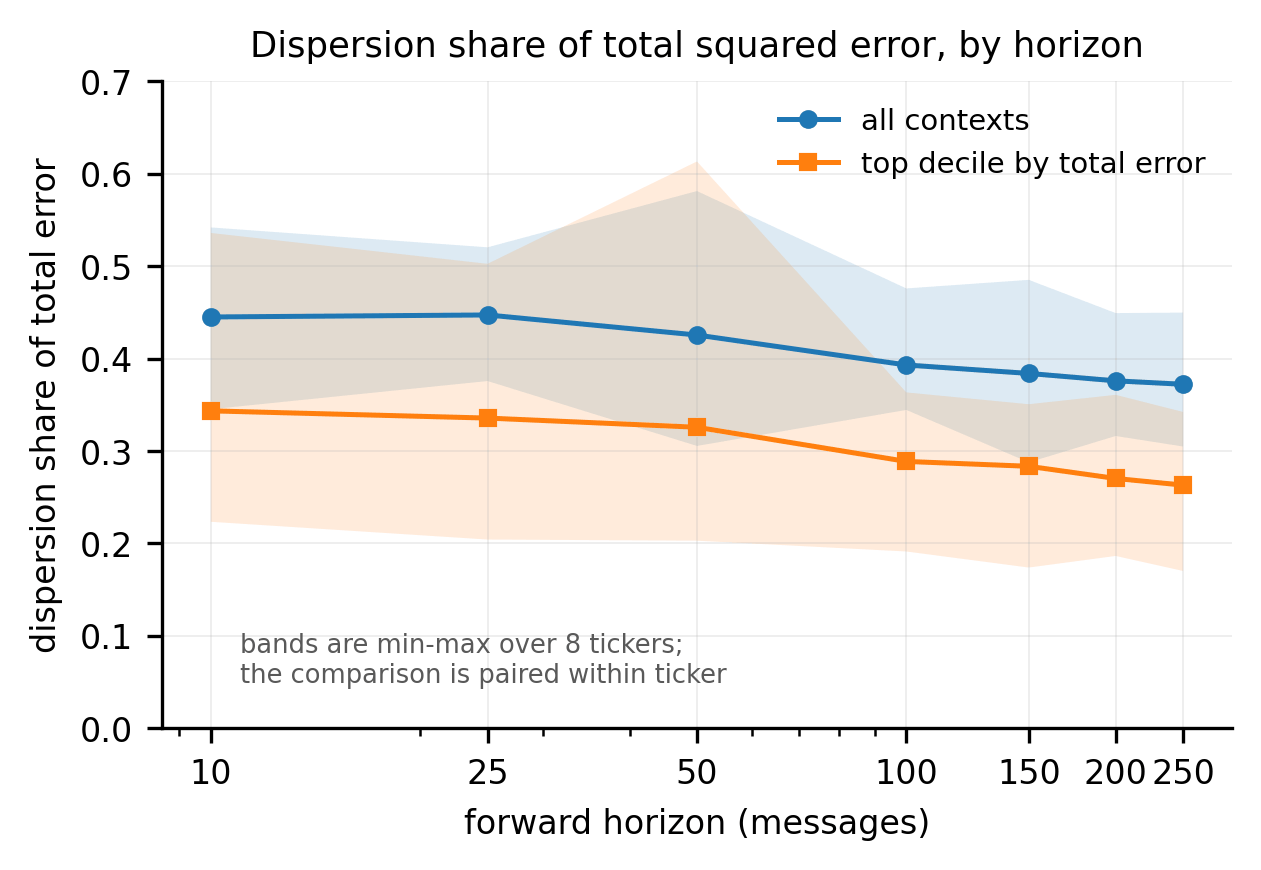

In [5]:
fig, ax = plt.subplots(figsize=(4.6, 2.8))
per = {t: R["tickers"][t]["dispersion"]["per_horizon"] for t in TK}
for lab, key, mk in [("all contexts", "spread_share_all", "o"),
                     ("top decile by total error", "spread_share_top_decile", "s")]:
    M_ = np.array([[p[key] for p in per[t]] for t in TK])
    ax.plot(HZ, M_.mean(0), mk + "-", lw=1.2, ms=3.5, label=lab)
    ax.fill_between(HZ, M_.min(0), M_.max(0), alpha=0.15)
ax.set_xscale("log"); ax.set_xticks(HZ); ax.set_xticklabels(HZ)
ax.set_xlabel("forward horizon (messages)")
ax.set_ylabel("dispersion share of total error")
ax.set_ylim(0, 0.7); ax.legend(fontsize=7)
ax.set_title("Dispersion share of total squared error, by horizon", fontsize=8.5)
ax.text(11, 0.05, "bands are min-max over 8 tickers;\nthe comparison is paired within ticker",
        fontsize=6.2, color="0.35")
show(fig)

In [6]:
n_lower = []
for i, h in enumerate(HZ):
    d = [(R["tickers"][t]["dispersion"]["per_horizon"][i]["spread_share_top_decile"],
          R["tickers"][t]["dispersion"]["per_horizon"][i]["spread_share_all"]) for t in TK]
    n_lower.append((h, sum(a < b for a, b in d), np.mean([b - a for a, b in d])))
print("top decile vs all contexts, paired within ticker (the bands above overlap; the")
print("pairing is what carries the comparison):")
for h, n, dm in n_lower:
    print(f"    horizon {h:>3}: lower in {n}/8 tickers, mean difference {dm:+.3f}")

top decile vs all contexts, paired within ticker (the bands above overlap; the
pairing is what carries the comparison):
    horizon  10: lower in 8/8 tickers, mean difference +0.102
    horizon  25: lower in 8/8 tickers, mean difference +0.112
    horizon  50: lower in 7/8 tickers, mean difference +0.100
    horizon 100: lower in 8/8 tickers, mean difference +0.104
    horizon 150: lower in 8/8 tickers, mean difference +0.100
    horizon 200: lower in 8/8 tickers, mean difference +0.106
    horizon 250: lower in 8/8 tickers, mean difference +0.109


Two corrections to what this figure originally carried. The share plotted uses the
population variance (ddof = 0) against a denominator that is unbiased for
bias$^2 + \sigma^2$, so it **understates** the irreducible part by $k/(k-1)$, about 11
percent at $k=10$; and quoting a cross-ticker mean per horizon hid the spread. Per ticker
at horizon 50 the unbiased share runs **0.20-0.61 as measured today**, so one ticker's
ceiling on any training gain is near 32 percent while another's is near 77. The paired
within-ticker comparison (top decile lower than overall) does hold, 8/8 at every horizon
but one. The pool is bias-dominated on average, and on the worst ticker only barely. That is milder than the usual worry that the biggest divergences in
market data are all irreducible, but it is not negligible, and it rests on the model's
own spread being a fair stand-in for the conditional spread. The reliability slope of
this model family is 0.46-0.59, meaning it is under-dispersed, so this figure understates
the dispersion share rather than overstating it.

## Figure 5 — The corrected pool is a different pool, not a cleaner one

Left: how much of the naive top decile the corrected rule also selects. Right: how much
of a top-decile selection's advantage survives being re-scored on rollouts that did not
take part in the selection, which is the regression-to-the-mean the selection rule pays.

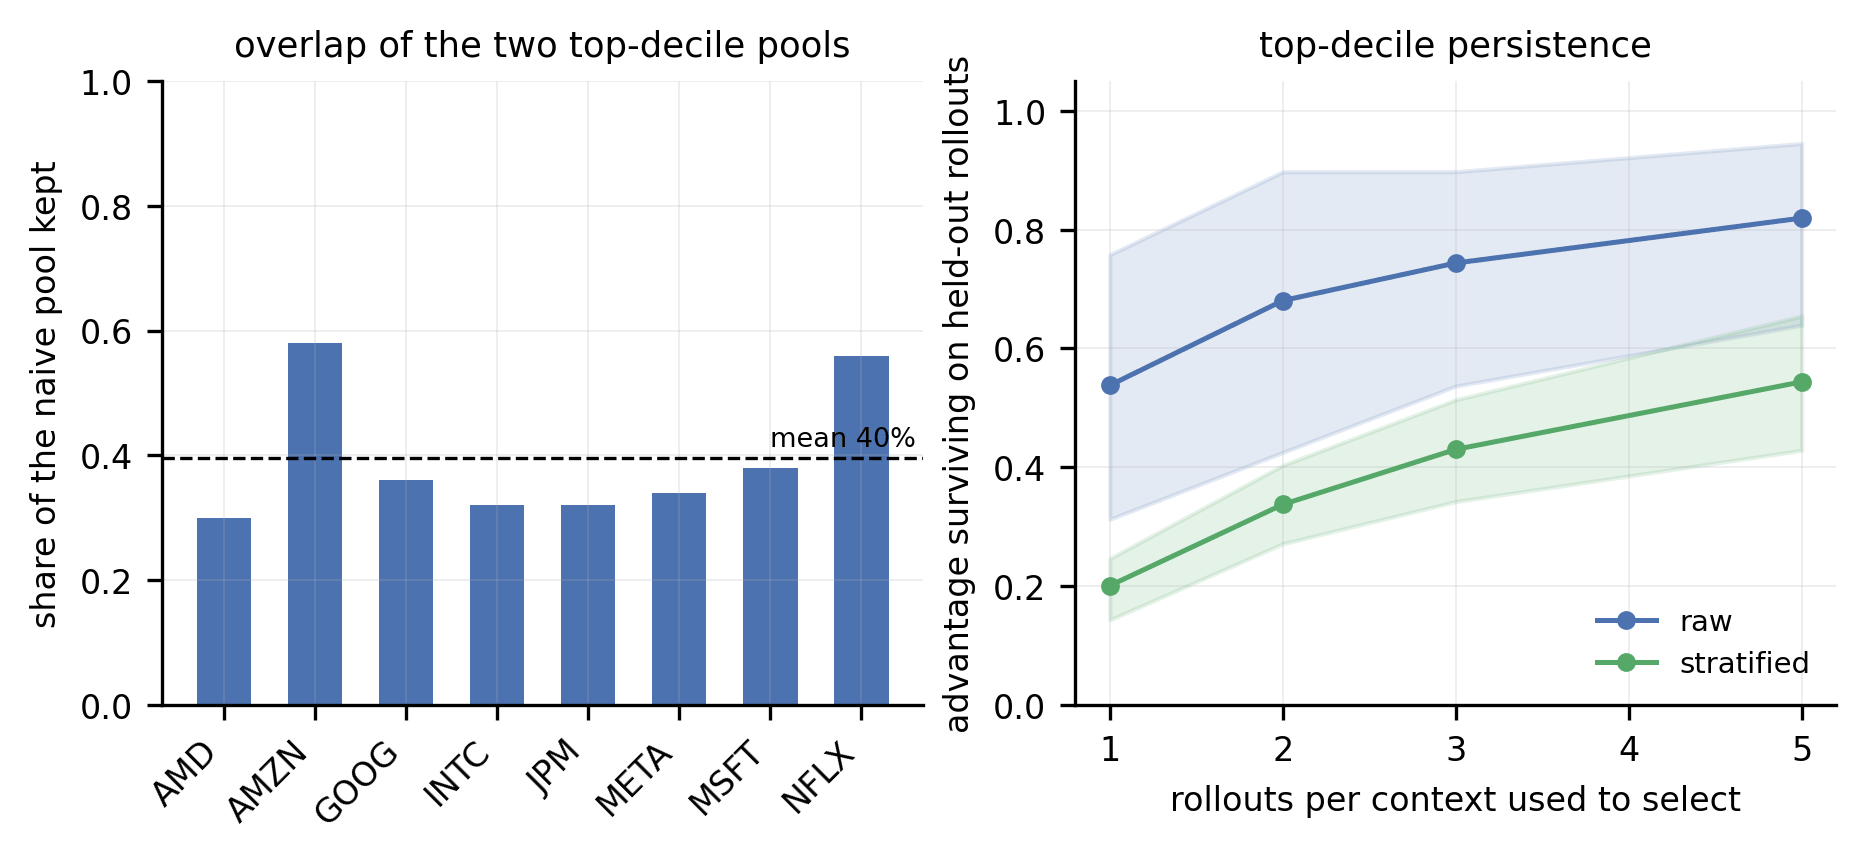

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.7))
ov = [R["tickers"][t]["pool_overlap_raw_vs_stratified"] for t in TK]
axes[0].bar(np.arange(len(TK)), ov, 0.6, color=CB[0])
axes[0].axhline(np.mean(ov), color="k", ls="--", lw=0.8)
axes[0].text(len(TK) - 0.4, np.mean(ov) + 0.02, f"mean {np.mean(ov):.0%}", fontsize=6.5, ha="right")
axes[0].set_xticks(np.arange(len(TK))); axes[0].set_xticklabels(TK, rotation=45, ha="right")
axes[0].set_ylabel("share of the naive pool kept"); axes[0].set_ylim(0, 1)
axes[0].set_title("overlap of the two top-decile pools", fontsize=8.5)

for key, lab, c in [("split_half_raw", "raw", CB[0]),
                    ("split_half_stratified", "stratified", CB[2])]:
    ks = [r["k"] for r in R["tickers"][TK[0]][key]]
    Mx = np.array([[r["top_decile_persistence"] for r in R["tickers"][t][key]] for t in TK])
    axes[1].plot(ks, Mx.mean(0), "o-", color=c, lw=1.2, ms=3.5, label=lab)
    axes[1].fill_between(ks, Mx.min(0), Mx.max(0), color=c, alpha=0.15)
axes[1].set_xlabel("rollouts per context used to select"); axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("advantage surviving on held-out rollouts")
axes[1].legend(fontsize=7); axes[1].set_title("top-decile persistence", fontsize=8.5)
show(fig)

The two pools share about 40 percent of their members, so this is not a matter of
cleaning up the edges of the naive pool. Sixty percent of what a naive rule would put in
front of the optimiser is different from what the corrected rule selects.

## Figure 6 — How many rollouts per context the pool actually needs

Two independent $k$-member estimates of one context's score correlate as
$\rho_k = s^2/(s^2 + n^2/k)$, so $1/\rho_k - 1$ is linear in $1/k$ through the origin
with slope $n^2/s^2$. One free parameter. The solid curve fits all four measured points; least squares on
$1/\rho - 1$ puts most of its weight on the small-$k$ end, so the dashed curve refits on
$k \geq 3$ alone. Where the two disagree, the dashed one is the relevant answer for
extrapolating to large $k$, and it is the more demanding of the two.

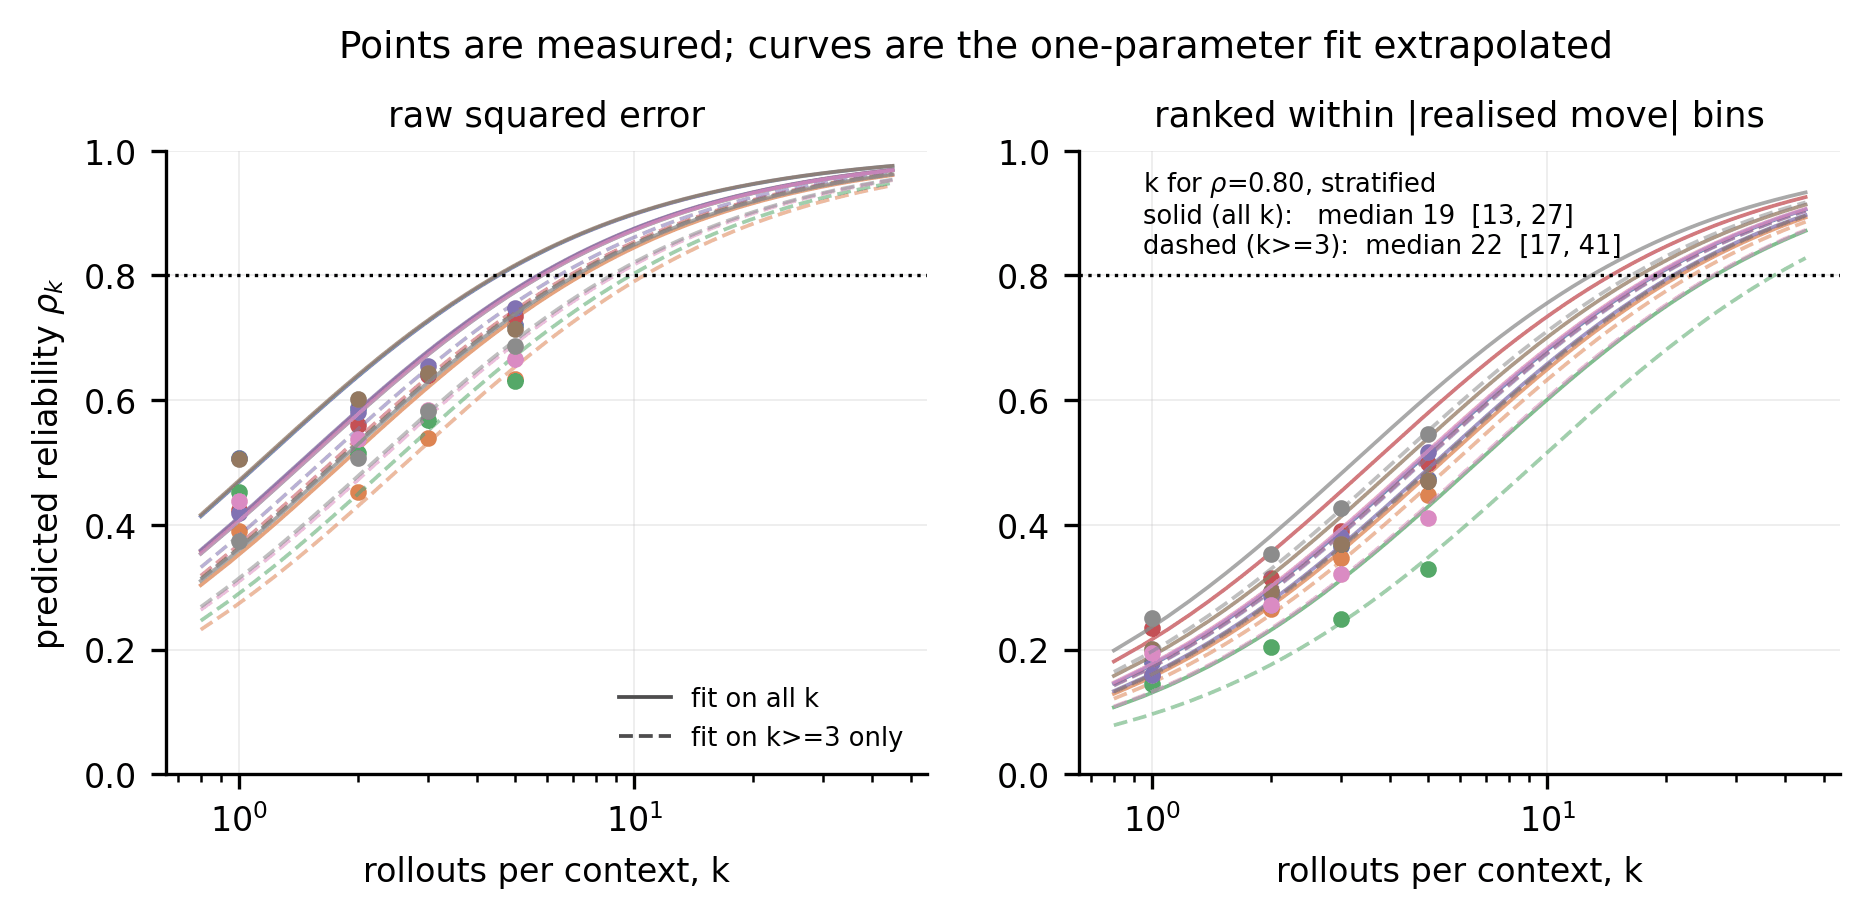

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.7))
for ax, key, title in zip(axes, ["split_half_raw", "split_half_stratified"],
                          ["raw squared error", "ranked within |realised move| bins"]):
    kk = np.linspace(0.8, 45, 300)
    for i, t in enumerate(TK):
        rows = R["tickers"][t][key]
        ks = np.array([r["k"] for r in rows]); rh = np.array([r["rho_mean"] for r in rows])
        # two fits: all four points, and the large-k end only. The second is the
        # honest one for extrapolating to large k, because the least-squares fit
        # on 1/rho - 1 puts most of its weight on the small-k points.
        for m, ls, al in ((ks > 0, "-", 0.75), (ks >= 3, "--", 0.55)):
            x, y = 1 / ks[m], 1 / rh[m] - 1
            sl = float((x * y).sum() / (x * x).sum())
            ax.plot(kk, 1 / (1 + sl / kk), ls, color=CB[i], lw=0.9, alpha=al)
        ax.plot(ks, rh, "o", color=CB[i], ms=3)
    ax.axhline(0.8, color="k", ls=":", lw=0.8)
    ax.set_xscale("log"); ax.set_xlabel("rollouts per context, k")
    ax.set_ylim(0, 1); ax.set_title(title, fontsize=8.5)
axes[0].set_ylabel(r"predicted reliability $\rho_k$")
# One estimator for every ticker. `k_for_rho_0.80` is emitted only when the
# one-parameter fit survives its own residual, so reading it per ticker builds an
# interval whose members were computed two different ways.
n_all = [R["tickers"][t]["k_needed_stratified"]["noise_over_signal"] / (1 / 0.80 - 1)
         for t in TK]
n_big = [R["tickers"][t]["k_needed_stratified"]["k_for_rho_0.80_largest_k_only"] for t in TK]
n_rej = sum("rejected_reason" in R["tickers"][t]["k_needed_stratified"] for t in TK)
axes[1].text(0.95, 0.97, "k for $\\rho$=0.80, stratified\n"
             f"solid (all k):   median {np.median(n_all):.0f}  [{min(n_all):.0f}, {max(n_all):.0f}]\n"
             f"dashed (k>=3):  median {np.median(n_big):.0f}  [{min(n_big):.0f}, {max(n_big):.0f}]",
             fontsize=6.2, va="top")
axes[0].plot([], [], "-", color="0.3", lw=0.9, label="fit on all k")
axes[0].plot([], [], "--", color="0.3", lw=0.9, label="fit on k>=3 only")
axes[0].legend(fontsize=6.2, loc="lower right")
fig.suptitle("Points are measured; curves are the one-parameter fit extrapolated",
             y=1.03, fontsize=9)
show(fig)

## Figure 7 — the confound on contexts the selection never saw

Contexts are split by content (sorted by id, even positions to FIT, odd to HELD), so the split
depends on no seed and no score. Every rule then selects and is scored **only on HELD**, which
the earlier figures did not do: they held out rollouts, and every context appeared on both
sides. Left: how much of the population's realised move each pool carries. Right: the cost of
freezing the stratum edges on FIT and applying them unchanged to HELD.

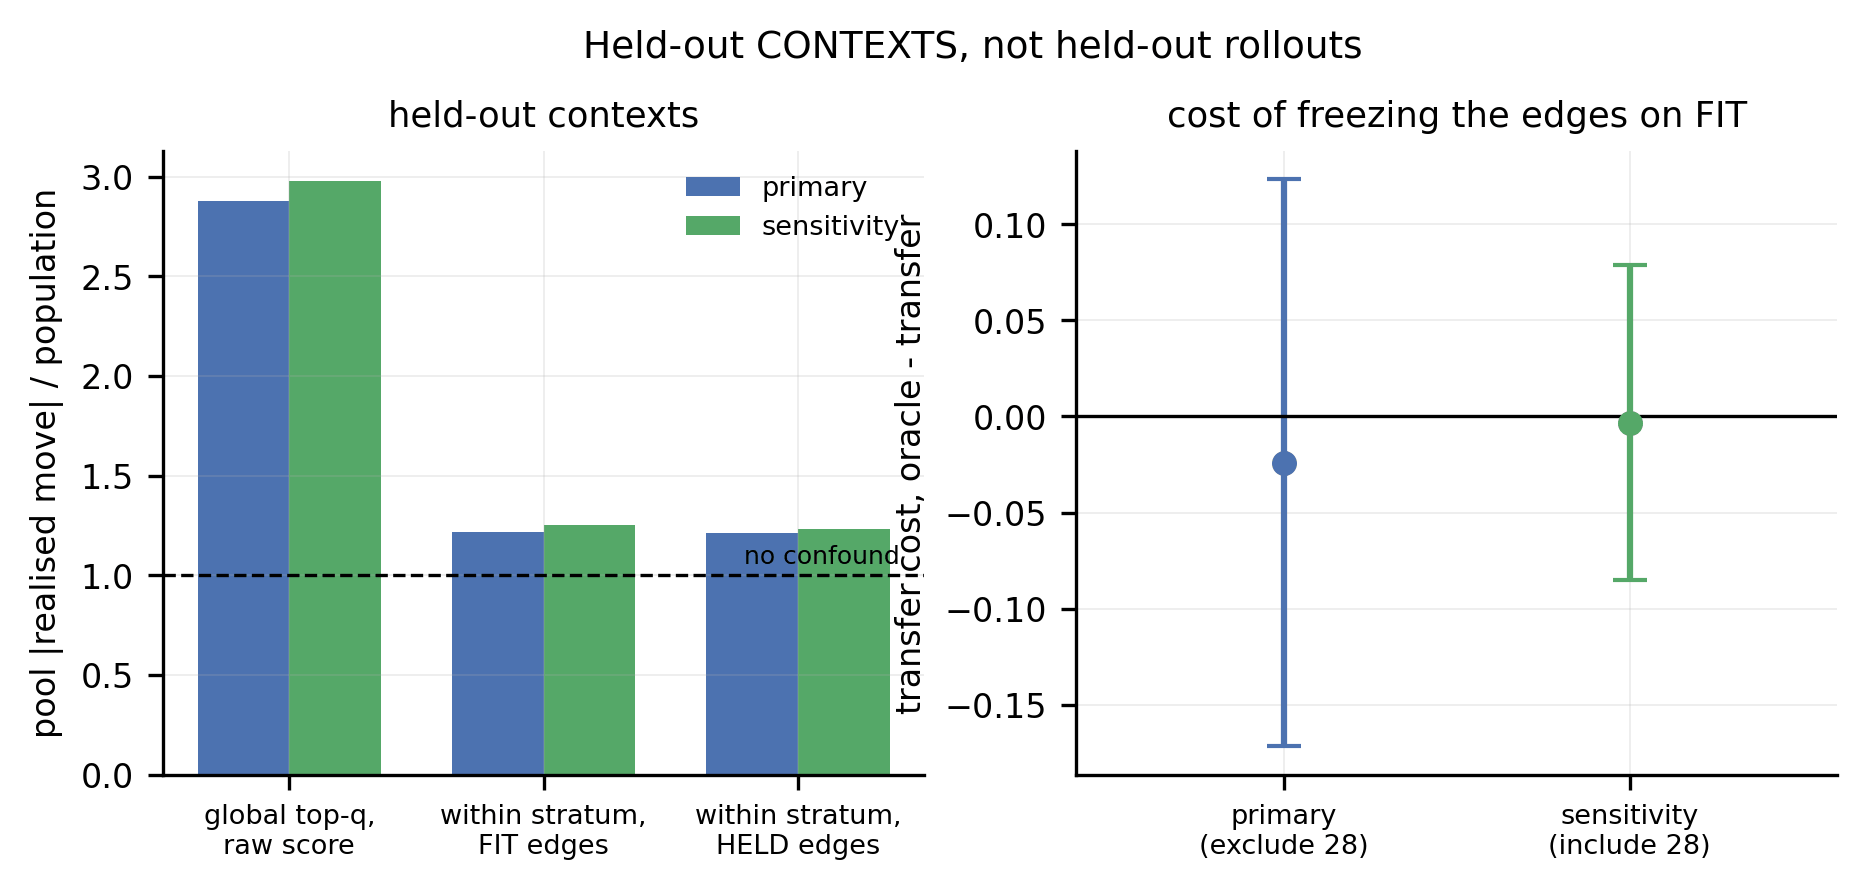

In [9]:
ch = json.loads((RES / "context_holdout_20260905.json").read_text())
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.7))
arms = ["T_global", "T_transfer", "T_oracle"]
lab = {"T_global": "global top-q,\nraw score", "T_transfer": "within stratum,\nFIT edges",
       "T_oracle": "within stratum,\nHELD edges"}
x = np.arange(len(arms))
for j, (an, c) in enumerate([("primary_exclude28", CB[0]), ("sensitivity_include28", CB[2])]):
    r = ch["analyses"][an]
    axes[0].bar(x + (j - 0.5) * 0.36, [np.mean([r[t][a]["bal"] for t in TK]) for a in arms],
                0.36, color=c, label=an.split("_")[0])
axes[0].axhline(1.0, color="k", ls="--", lw=0.8)
axes[0].text(2.4, 1.06, "no confound", fontsize=6, ha="right")
axes[0].set_xticks(x); axes[0].set_xticklabels([lab[a] for a in arms], fontsize=6.5)
axes[0].set_ylabel("pool |realised move| / population")
axes[0].set_title("held-out contexts", fontsize=8.5); axes[0].legend(fontsize=6.5)

for j, (an, c) in enumerate([("primary_exclude28", CB[0]), ("sensitivity_include28", CB[2])]):
    r = ch["analyses"][an]
    d = np.array([r[t]["T_oracle"]["Y_v2"] - r[t]["T_transfer"]["Y_v2"] for t in TK])
    axes[1].errorbar([j], [d.mean()], yerr=[d.std(ddof=1)], fmt="o", color=c, capsize=4, ms=5)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlim(-0.6, 1.6); axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["primary\n(exclude 28)", "sensitivity\n(include 28)"], fontsize=6.5)
axes[1].set_ylabel("transfer cost, oracle - transfer")
axes[1].set_title("cost of freezing the edges on FIT", fontsize=8.5)
fig.suptitle("Held-out CONTEXTS, not held-out rollouts", y=1.03, fontsize=9)
show(fig)

The literal issue-#73 rule carries **2.88-2.98x** the population's realised move on
contexts it never saw, against 1.21-1.25 for the stratified rules. The held-out-rollout
comparison put the same gap at 1.42 against 1.29, so **that test understates the confound by
about a factor of four** -- which is why the two are not interchangeable. The transfer cost
brackets zero under both analyses (|mean|/sd 0.16 and 0.04, direction a coin flip in both),
so the edges may be fitted once and reused. Neither panel says anything about training.

## Table 1 — Per ticker

In [10]:
hdr = f"{'ticker':>7} | {'k=1':>6} {'k=5':>6} | {'k=1':>6} {'k=5':>6} | {'n/s':>5} {'k@.80':>6} {'k@.90':>6} {'fit':>4} | {'overlap':>7}"
print(f"{'':>7} | {'raw rho':^13} | {'stratified rho':^13} | {'k from the largest-k point':^26} |")
print("REJ marks a ticker whose one-parameter fit its own residual rejects; k is the")
print("largest-k estimator for EVERY ticker, so the interval is one estimator throughout.")
print(hdr); print("-" * len(hdr))
for t in TK:
    v = R["tickers"][t]
    g = lambda key, k: next(r["rho_mean"] for r in v[key] if r["k"] == k)
    kn = v["k_needed_stratified"]
    print(f"{t:>7} | {g('split_half_raw',1):>6.3f} {g('split_half_raw',5):>6.3f} | "
          f"{g('split_half_stratified',1):>6.3f} {g('split_half_stratified',5):>6.3f} | "
          f"{kn['noise_over_signal']:>5.2f} {kn['k_for_rho_0.80_largest_k_only']:>6.0f} "
          f"{kn['k_for_rho_0.90_largest_k_only']:>6.0f} {'REJ' if 'rejected_reason' in kn else '   ':>4} | "
          f"{v['pool_overlap_raw_vs_stratified']:>6.0%}")

        |    raw rho    | stratified rho | k from the largest-k point |
REJ marks a ticker whose one-parameter fit its own residual rejects; k is the
largest-k estimator for EVERY ticker, so the interval is one estimator throughout.
 ticker |    k=1    k=5 |    k=1    k=5 |   n/s  k@.80  k@.90  fit | overlap
----------------------------------------------------------------------------
    AMD |  0.507  0.720 |  0.180  0.474 |  4.69     22     50      |    30%
   AMZN |  0.389  0.634 |  0.159  0.447 |  5.39     25     56      |    58%
   GOOG |  0.453  0.631 |  0.144  0.330 |  6.64     41     91  REJ |    36%
   INTC |  0.424  0.735 |  0.235  0.498 |  3.62     20     45  REJ |    32%
    JPM |  0.418  0.748 |  0.159  0.516 |  5.19     19     42      |    32%
   META |  0.506  0.714 |  0.201  0.471 |  4.27     23     51  REJ |    34%
   MSFT |  0.439  0.665 |  0.194  0.411 |  4.63     29     64  REJ |    38%
   NFLX |  0.374  0.687 |  0.250  0.545 |  3.23     17     37  REJ |    56%


## Table 2 — Two complete regenerations of the same configuration

`v5me3repro` and `v5me3repB` are the identical setup, identical seeds, generated twice.
Because the seeds are shared, this isolates the generation-nondeterminism layer alone,
which the split-half figures cannot see: they draw disjoint seeds and so mix
nondeterminism with genuine sampling of the conditional.

In [11]:
print(f"{'ticker':>7} | {'k':>2} | {'rho':>6} | {'top-decile persistence':>22}")
print("-" * 48)
vals = []
for t in TK:
    n = R["null"].get(t, {})
    if "rho_mean" in n:
        print(f"{t:>7} | {n['k']:>2} | {n['rho_mean']:>6.3f} | {n['top_decile_persistence']:>22.3f}")
        vals.append(n["rho_mean"])
print(f"\nSame seeds, re-run: rho = {np.mean(vals):.3f}. Roughly {(1-np.mean(vals))*100:.0f}% of the")
print("rank agreement is lost to generation nondeterminism before any sampling of the")
print("conditional is involved. Setting --xla_gpu_autotune_level=0 removes it at 1.49x wall clock.")

 ticker |  k |    rho | top-decile persistence
------------------------------------------------
    AMD |  4 |  0.813 |                  0.848
   AMZN |  4 |  0.837 |                  0.836
   GOOG |  4 |  0.726 |                  0.783
   INTC |  4 |  0.824 |                  0.856
    JPM |  4 |  0.777 |                  0.865
   META |  4 |  0.804 |                  0.893
   MSFT |  4 |  0.805 |                  0.882
   NFLX |  4 |  0.875 |                  0.850

Same seeds, re-run: rho = 0.808. Roughly 19% of the
rank agreement is lost to generation nondeterminism before any sampling of the
conditional is involved. Setting --xla_gpu_autotune_level=0 removes it at 1.49x wall clock.


## What this settles

1. **One rollout per context is not enough to build a pool.** Split-half reliability of the
   raw score at $k=1$ is 0.36-0.48; of the corrected score, 0.15-0.25. The one-parameter fit
   is **rejected by its own residuals**: the implied noise/signal ratio $(1/\rho_k-1)\,k$
   rises with $k$ in 7 of 8 tickers, and least squares through the origin on $1/k$ is
   dominated by the $k=1$ point, so it extrapolates $k$ **low**. Reading the largest-$k$
   point uniformly for every ticker gives **17-41, median 22**, still rising. No
   extrapolation from $k \leq 5$ is supported, and this figure is **not used as a budget**.
   Rollouts per context is the first budget decision, ahead of any mix ratio.

2. **The obvious score is mostly not about the model.** Raw squared error correlates 0.65
   with the size of the realised move and keeps 0.46 of its ranking when rollouts are
   detached from their contexts. Ranking inside realised-move bins removes both (0.03 and
   0.10) and keeps genuine signal, with `cross` collapsing onto the zero line. The two
   resulting pools overlap by only about 40 percent.

3. **Reliability is not sufficient evidence.** A consistently mis-paired score is as
   reliable as the correct one. Only the cross-pairing null distinguishes them.

4. **Dispersion is a large minority of the selected-on quantity**, 26-34 percent inside the
   top decile, and the model is under-dispersed, so that is a floor. Splitting the error and
   selecting on the systematic part is cheap once $k$ rollouts per context exist anyway.

5. **Generation nondeterminism costs about 15 percent of rank agreement on its own**, before
   any sampling of the conditional. It is removable at 1.49x wall clock on the evaluation
   path only.

None of this settles the mix ratio, and none of it needed a GPU. It does mean the
70/30-versus-100-percent question in the issue is downstream of a pool that does not yet
exist in a usable form.